In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64


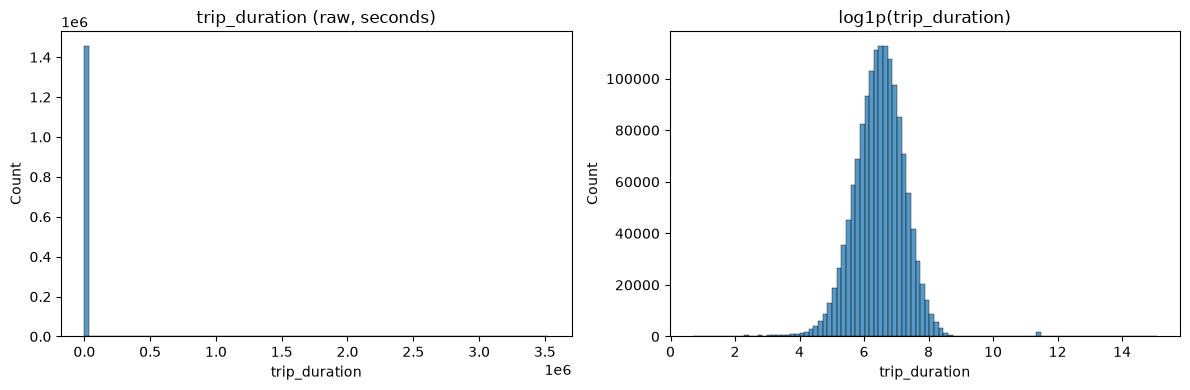

978383     3526282
924150     2227612
680594     2049578
355003     1939736
1234291      86392
295382       86391
73816        86390
59891        86387
1360439      86385
753765       86379
Name: trip_duration, dtype: int32
Max duration in hours: 979.5


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load import load_raw_data

df = load_raw_data("../data/raw/train.csv")  # adjust path if running from notebooks/

print(df["trip_duration"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["trip_duration"], bins=100, ax=axes[0])
axes[0].set_title("trip_duration (raw, seconds)")

sns.histplot(np.log1p(df["trip_duration"]), bins=100, ax=axes[1])
axes[1].set_title("log1p(trip_duration)")
plt.tight_layout()
plt.show()

# Explicit look at the extreme tail
print(df["trip_duration"].sort_values(ascending=False).head(10))
print(f"Max duration in hours: {df['trip_duration'].max() / 3600:.1f}")

passenger_count
0         60
1    1033540
2     210318
3      59896
4      28404
5      78088
6      48333
7          3
8          1
9          1
Name: count, dtype: int64


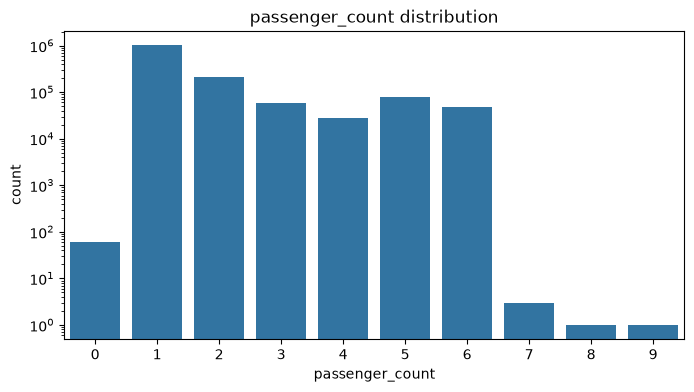

In [4]:
print(df["passenger_count"].value_counts().sort_index())

plt.figure(figsize=(8, 4))
sns.countplot(x=df["passenger_count"])
plt.title("passenger_count distribution")
plt.yscale("log")  # counts vary by orders of magnitude
plt.show()

       pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude
count      1.458644e+06     1.458644e+06       1.458644e+06      1.458644e+06
mean      -7.397348e+01     4.075092e+01      -7.397342e+01      4.075180e+01
std        7.090186e-02     3.288119e-02       7.064327e-02      3.589055e-02
min       -1.219333e+02     3.435970e+01      -1.219333e+02      3.218114e+01
25%       -7.399187e+01     4.073735e+01      -7.399133e+01      4.073588e+01
50%       -7.398174e+01     4.075410e+01      -7.397975e+01      4.075452e+01
75%       -7.396733e+01     4.076836e+01      -7.396301e+01      4.076981e+01
max       -6.133553e+01     5.188108e+01      -6.133553e+01      4.392103e+01


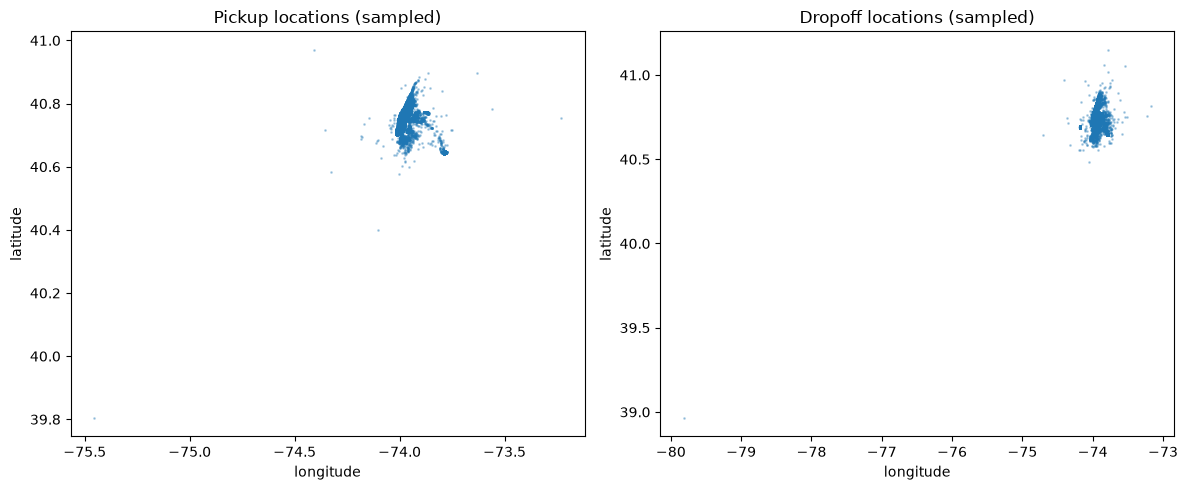

49982 / 50000 sampled rows fall inside a rough NYC bounding box


In [5]:
coord_cols = ["pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude"]
print(df[coord_cols].describe())

# Sample for plotting — 1.45M points would overplot and be slow to render
sample = df.sample(50_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(sample["pickup_longitude"], sample["pickup_latitude"], s=1, alpha=0.3)
axes[0].set_title("Pickup locations (sampled)")
axes[0].set_xlabel("longitude"); axes[0].set_ylabel("latitude")

axes[1].scatter(sample["dropoff_longitude"], sample["dropoff_latitude"], s=1, alpha=0.3)
axes[1].set_title("Dropoff locations (sampled)")
axes[1].set_xlabel("longitude"); axes[1].set_ylabel("latitude")
plt.tight_layout()
plt.show()

# Zoomed view restricted to a known-reasonable NYC bounding box, for comparison
nyc_box = sample[
    (sample["pickup_longitude"].between(-74.05, -73.70)) &
    (sample["pickup_latitude"].between(40.55, 40.90))
]
print(f"{len(nyc_box)} / {len(sample)} sampled rows fall inside a rough NYC bounding box")

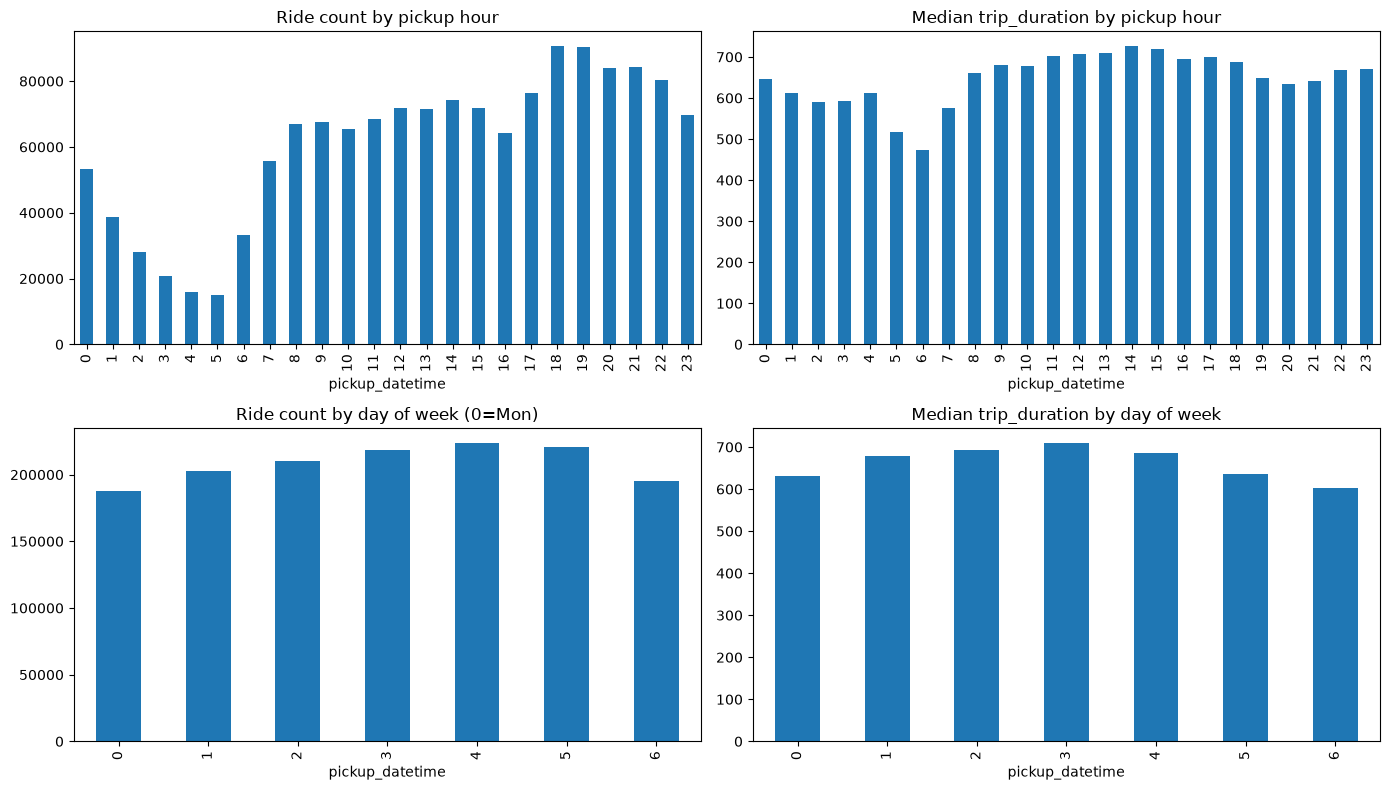

In [6]:
# Temporary, exploratory-only columns — not saved, not reused elsewhere
eda_hour = df["pickup_datetime"].dt.hour
eda_dow = df["pickup_datetime"].dt.dayofweek  # 0=Monday

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df.groupby(eda_hour).size().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Ride count by pickup hour")

df.groupby(eda_hour)["trip_duration"].median().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Median trip_duration by pickup hour")

df.groupby(eda_dow).size().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Ride count by day of week (0=Mon)")

df.groupby(eda_dow)["trip_duration"].median().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Median trip_duration by day of week")

plt.tight_layout()
plt.show()

In [7]:
# Simplified/approximate distance for EDA purposes only (equirectangular approx,
# fine for flagging outliers, not precise enough for the final feature)
lat_diff = df["dropoff_latitude"] - df["pickup_latitude"]
lon_diff = df["dropoff_longitude"] - df["pickup_longitude"]
eda_dist_km = np.sqrt(lat_diff**2 + lon_diff**2) * 111  # ~111 km per degree

eda_speed_kmh = eda_dist_km / (df["trip_duration"] / 3600)

print("Implied speed (km/h) summary:")
print(eda_speed_kmh.describe())

# How many trips imply a physically absurd speed?
too_fast = (eda_speed_kmh > 120).sum()   # faster than highway speed, in NYC traffic
too_slow_long = ((eda_speed_kmh < 1) & (df["trip_duration"] > 600)).sum()  # crawling for 10+ min
zero_distance = (eda_dist_km < 0.01).sum()

print(f"Trips implying >120 km/h: {too_fast}")
print(f"Trips implying <1 km/h sustained for >10 min: {too_slow_long}")
print(f"Trips with ~zero distance: {zero_distance}")

Implied speed (km/h) summary:
count    1.458644e+06
mean     1.628641e+01
std      1.701553e+01
min      0.000000e+00
25%      1.030139e+01
50%      1.437035e+01
75%      1.995963e+01
max      1.075750e+04
dtype: float64
Trips implying >120 km/h: 160
Trips implying <1 km/h sustained for >10 min: 6155
Trips with ~zero distance: 8519
